In [1]:
import os
os.getcwd()

from pathlib import Path
from stgae.config.load_config import load_config
from stgae.data.preproccesing import get_columns
import pandas as pd

paths = load_config()['paths']    
data_path = Path(paths['raw_data'])

df = pd.read_csv(data_path / 'data.txt', names=get_columns(), sep=' ')
print(df.columns)

Index(['date', 'time', 'epoch', 'moteid', 'temperature', 'humidity', 'light',
       'voltage'],
      dtype='object')


I dropped all the rows with missing data about the sensor id (few)

In [2]:
# drop rows where moteid is NaN
df = df.dropna(subset=['moteid']).reset_index(drop=True) #526 observations

#i concatenate date and time columns into a single datetime column
# parse flexibly to handle mixed time formats without raising
dt_series = pd.to_datetime(df['date'] + ' ' + df['time'], infer_datetime_format=True, errors='coerce')

# try a stricter fallback for entries that failed (e.g., strings without microseconds)
if dt_series.isna().any():
	mask = dt_series.isna()
	dt_series.loc[mask] = pd.to_datetime(
		df.loc[mask, 'date'] + ' ' + df.loc[mask, 'time'],
		format='%Y-%m-%d %H:%M:%S',
		errors='coerce'
	)

df['datetime'] = dt_series

assert not df['datetime'].isna().any(), "Some datetime entries could not be parsed."

df = df.drop(columns=['date', 'time'])

/var/folders/3g/nq3drgr156qd7b6wgdbymtv80000gn/T/ipykernel_70607/1314420742.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_series = pd.to_datetime(df['date'] + ' ' + df['time'], infer_datetime_format=True, errors='coerce')


In this dataset, an epoch is indeed a discretization of time. The sensors were programmed to wake up, sense, and transmit data periodically (roughly every 31 seconds). However, because these are independent, low-power Mica2Dot motes:

Clock Drift: Their internal clocks drift over time.

Retransmission: If a packet fails, a sensor might retry, potentially leading to duplicates or delayed arrival timestamps that get binned into the same epoch bucket.

Topology: The epoch number is often derived from the aggregation station or assigned based on time windows. If a sensor samples at the very end of one window and the start of the next, or samples twice due to a glitch, you get collisions.

Because of this, there are epochs with more than one observation per sensor. Since I want to model features as a function of (epoch, moteid), I aggregate the features grouping by (epoch, moteid). In particular, I take the average of the features, and keep the earliest datetime.

In [3]:
# Define a dictionary mapping columns to their aggregation method
aggregation_rules = {
    'temperature': 'mean',    # Average the sensor values
    'humidity': 'mean',
    'light': 'mean',
    'voltage': 'mean',
    'datetime': 'min'        # Take the earliest timestamp for this epoch
}

df = df.groupby(['epoch', 'moteid']).agg(aggregation_rules).reset_index()

Now I count the average number of sensors per epoch. 

In [4]:
df.groupby('epoch').size().mean()

np.float64(33.562408447265625)

We have approximately 33.5 measurements per epoch. Given that the original data comes from 54 sensors... I study if there are particular sensors that have very little data.

In [5]:
number_of_epochs = df['epoch'].nunique()
(df.groupby('moteid').size().sort_values() / number_of_epochs).iloc[:20]

moteid
65407.0    0.000015
6485.0     0.000015
33117.0    0.000015
57.0       0.000046
5.0        0.000534
15.0       0.035660
56.0       0.038254
55.0       0.043381
58.0       0.068680
50.0       0.240189
8.0        0.255753
12.0       0.349762
53.0       0.426178
20.0       0.439987
13.0       0.476715
14.0       0.480804
39.0       0.489014
17.0       0.514679
52.0       0.515900
33.0       0.525604
dtype: float64

I observed that there are some possibly mislabled sensors (65407, 6485, 33117, 56, 58, 57, 55) and some sensors with very little data (5, 18, 50, 8, 12). I discarded them entirely.

In [6]:
discard = [65407, 6485, 33117, 56, 58, 57, 5, 18, 50, 8, 12, 55]
df = df[~df['moteid'].isin(discard)]
df['moteid'].unique()

array([11., 19., 21., 47., 52., 13., 14.,  1.,  2.,  3.,  4.,  6., 15.,
       16., 17., 20., 22., 23., 24., 25., 26., 27., 28., 31., 34., 35.,
       38., 40., 42., 43., 45., 46., 48., 49., 54., 32., 51., 29., 33.,
       30., 10., 36.,  7.,  9., 53., 37., 44., 41., 39.])

I observed that feature light is missing in plenty observations.

In [7]:
df.isna().sum() / len(df)

epoch          0.000000
moteid         0.000000
temperature    0.000081
humidity       0.000081
light          0.038438
voltage        0.000000
datetime       0.000000
dtype: float64

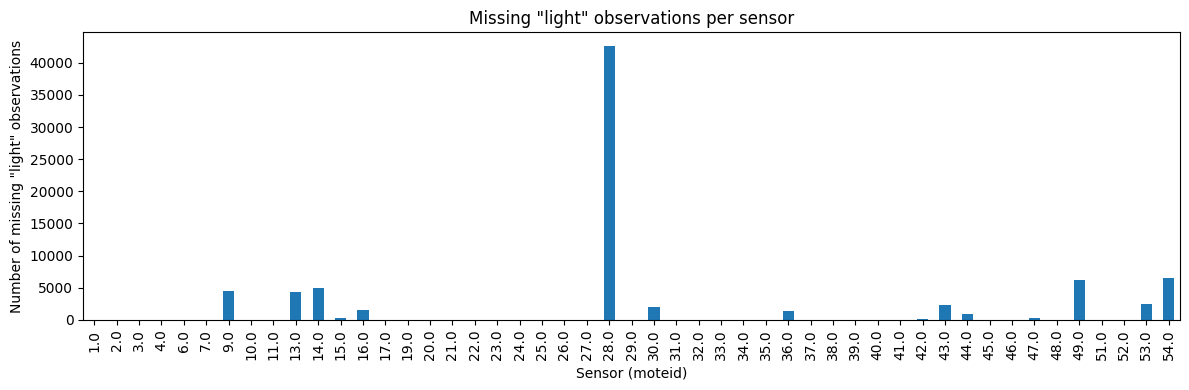

In [8]:
import matplotlib.pyplot as plt

missing_counts = df.groupby('moteid')['light'].apply(lambda x: x.isna().sum()).sort_index()

plt.figure(figsize=(12,4))
missing_counts.plot(kind='bar')
plt.xlabel('Sensor (moteid)')
plt.ylabel('Number of missing "light" observations')
plt.title('Missing "light" observations per sensor')
plt.tight_layout()
plt.show()

Sensor 28 has too many observations where the feature light is missing. I discard it as well.

In [9]:
df = df[df['moteid'] != 28]

df.isna().sum() / len(df)

epoch          0.000000
moteid         0.000000
temperature    0.000083
humidity       0.000082
light          0.018512
voltage        0.000000
datetime       0.000000
dtype: float64

Remaining missing data is little compared to the size of the dataset. I drop the rows with missing data. Then, I observed that there are epochs with more than one observation per sensors. This happens because epochs is in the end a (given by the dataset) discretization of time. Therefore, in order to treat this as a time series, I aggregated (averaged) observed features per epoch.

In [10]:
df = df.dropna().reset_index(drop=True)

Finally I reindexed epochs and sensors ids.

In [11]:
#rename moteid
moteid_mapping = {old_id: new_id for new_id, old_id in enumerate(sorted(df['moteid'].unique()))}
df['moteid'] = df['moteid'].map(moteid_mapping)

first_epoch = df['epoch'].min()
df['epoch'] = df['epoch'] - first_epoch

assert df['epoch'].max() == df['epoch'].nunique()-1 #all epochs are present
print(len(df['epoch'].unique()))

65536


Let's build the graph.
I decided to use a graph using knn (with k=5), and the edges weighted according to the inverse of the distance. 

Building adjacency matrix

In [12]:
from stgae.data.preproccesing import calculate_distances, calculate_adjacency_matrix

coordinates = pd.read_csv(paths['data_root'] / 'sensor_coordinates.txt', sep=' ')

dist_matrix = calculate_distances(coordinates) #numpy array

k=3 #for k-nearest neighbors adj matrix
exclude_sensors = [28, 5, 18, 50, 8, 12]

A = calculate_adjacency_matrix(dist_matrix, k=k, exclude=exclude_sensors) #assumes renaming of moteid, according to excluded sensors

assert A.shape[0] == len(df['moteid'].unique())

Now, I built the tensors to then create the Dataset.
I created X and M, of shapes
X: shape (T, N, F)
M: shape (T, N, 1)
where
X[t, n] = features of sensor n at epoch t
M[t, n] = 1 if sensor exists at epoch t, else 0

In [13]:
from stgae.data.preproccesing import build_tensors

#shapes:
#X: (time_steps, num_sensors, num_features)
#M: (time_steps, num_sensors)
X, M = build_tensors(df, epochs=df['epoch'].unique(), sensors=df['moteid'].unique(), feature_cols=['temperature', 'humidity', 'light', 'voltage'])

Now lets build the dataset.  <br>
For a center time t, and a window size W: <br>
past window: [t-W, ..., t] <br>
future window: [t, ..., t+W] <br>

Masking: masking sensor level per window, that is, for each timestep, choose a subset of known sensors at that the center timestep and mask them in that timestep

In [14]:
from stgae.data.dataset import STBGNNDataset
from stgae.data.preproccesing import StandardScaler

train_split = 0.9
T = X.shape[0]
train_size = int(T * train_split)

#divide into train and val, keeping temporal order, to avoid leakage and learn temporal dependencies
X_train = X[:train_size]
X_val = X[train_size:]

#i fit the scalar on the training data only to prevent leakeage
scaler = StandardScaler()
scaler.fit(X_train)

train_norm = scaler.transform(X_train)
val_norm = scaler.transform(X_val)

train_dataset = STBGNNDataset(train_norm, M, window_size=4, mask_ratio=0.5, split="train")
val_dataset = STBGNNDataset(val_norm, M, window_size=4, mask_ratio=0.5, split="test")

for k in train_dataset[0].keys():
    print(f'{k}: {train_dataset[0][k].shape}')

print('train dataset length:', len(train_dataset))

x_past_masked: torch.Size([5, 48, 4])
x_future_masked: torch.Size([5, 48, 4])
target: torch.Size([48, 4])
loss_mask: torch.Size([48])
train dataset length: 58975


Note that masking in the training dataset is stochastic, while masking in the test dataset is deterministic. This is implemented using a local_rng for the test dataset (see code)

Training the model

In [15]:
import torch
from torch.utils.data import DataLoader
from stgae.model.bistgcn_opt import BiSTGCN
from stgae.model.train import train_step
from stgae.config.load_config import load_config
from stgae.model.evaluate import evaluate

# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 2
LEARNING_RATE = 1e-3
HIDDEN_DIM = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = load_config()["paths"]["checkpoints"] #dir to store models

os.makedirs(SAVE_DIR, exist_ok=True)

# dataloader
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) #this does not shuffle timesteps inside samples, but samples inside the batches and improves SGD 
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = BiSTGCN(in_features=train_dataset.F, hidden_dim=HIDDEN_DIM, adj=A).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
best_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    for batch_idx, batch in enumerate(train_dataloader):
        loss = train_step(batch, model, optimizer, DEVICE)
        train_loss += loss

        if batch_idx % 200 == 0:
            print(f"   Batch {batch_idx+1}/{len(train_dataloader)} - Train Loss: {loss:.6f}")
    avg_train_loss = train_loss / len(train_dataloader)

    val_mse, val_mae, val_rmse = evaluate(val_dataloader, model, DEVICE)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"   Train Loss: {avg_train_loss:.6f}")
    print(f"   Val MSE:    {val_mse:.6f}")
    print(f"   Val MAE:    {val_mae:.6f}")
    print(f"   Val RMSE:   {val_rmse:.6f}")

    if val_mse < best_loss:
        best_loss = val_mse
        best_path = os.path.join(SAVE_DIR, "bistgcn_best.pth")
        torch.save(model.state_dict(), best_path)
        print(f"   -> New best model saved to {best_path}")

    # 2. Save Checkpoint (For Resuming)
    # We save this every epoch. It includes optimizer state.
    checkpoint_path = os.path.join(SAVE_DIR, "bistgcn_last.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': avg_train_loss,
        'loss': val_mse,
    }, checkpoint_path)

   Batch 1/1843 - Train Loss: 1.091325
   Batch 101/1843 - Train Loss: 0.044498
   Batch 201/1843 - Train Loss: 0.011000
   Batch 301/1843 - Train Loss: 0.008483
   Batch 401/1843 - Train Loss: 0.007331
   Batch 501/1843 - Train Loss: 0.004857
   Batch 601/1843 - Train Loss: 0.004289
   Batch 701/1843 - Train Loss: 0.003638
   Batch 801/1843 - Train Loss: 0.004049
   Batch 901/1843 - Train Loss: 0.003225
   Batch 1001/1843 - Train Loss: 0.002705
   Batch 1101/1843 - Train Loss: 0.002566
   Batch 1201/1843 - Train Loss: 0.002894
   Batch 1301/1843 - Train Loss: 0.002541
   Batch 1401/1843 - Train Loss: 0.002185
   Batch 1501/1843 - Train Loss: 0.002033
   Batch 1601/1843 - Train Loss: 0.002152
   Batch 1701/1843 - Train Loss: 0.001880
   Batch 1801/1843 - Train Loss: 0.001945
Epoch [1/2]
   Train Loss: 0.022849
   Val MSE:    0.473958
   Val MAE:    0.406149
   Val RMSE:   0.685648
   -> New best model saved to /Users/teonabot/Desktop/unibo/aiind/project/STGAE-for-anomaly-detection/src/